In [43]:
# ============================================================
# PROJET : Prévision des ventes Walmart
# BLOC A  : Préparation des données
# A1      : Importation & Fusion
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

print("Librairies chargées ✓")

Librairies chargées ✓


In [44]:
# A1 — Chargement des fichiers bruts

train    = pd.read_csv("train.csv",    parse_dates=["Date"])
stores   = pd.read_csv("stores.csv")
features = pd.read_csv("features.csv", parse_dates=["Date"])
test     = pd.read_csv("test.csv",     parse_dates=["Date"])

for name, df in [("train", train), ("stores", stores),
                 ("features", features), ("test", test)]:
    print(f"\n{name.upper()} — {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
    display(df.head(3))


TRAIN — 421,570 lignes x 5 colonnes


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False



STORES — 45 lignes x 3 colonnes


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392



FEATURES — 8,190 lignes x 12 colonnes


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False



TEST — 115,064 lignes x 4 colonnes


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False


In [45]:
# A1 - Fusion des fichiers

# Étape 1 : train + stores
df = train.merge(stores, on="Store", how="left")

# Étape 2 : résultat + features
df = df.merge(features, on=["Store", "Date"], how="left")

print(f"Dimensions après fusion : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
display(df.head(3))

Dimensions après fusion : 421,570 lignes x 17 colonnes


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False


In [46]:
# A1 - Vérification des colonnes

print(df.columns.tolist())
print()
print(df.dtypes)

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y']

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday_x               bool
Type                    object
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday_y               bool
dtype: object


In [47]:
# A1 - Nettoyage des colonnes dupliquées après merge

# IsHoliday est présent dans train ET features — on garde une seule version
df = df.drop(columns=["IsHoliday_y"])
df = df.rename(columns={"IsHoliday_x": "IsHoliday"})

print(f"Colonnes finales : {df.shape[1]}")
print(df.columns.tolist())

Colonnes finales : 16
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


In [48]:
df.shape

(421570, 16)

In [49]:
# A2 / Analyse Exploratoire (EDA)

# Types de données
print("Types de données")
print(df.dtypes)
print()

# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes" : missing,
    "Pourcentage (%)"    : missing_pct
})
missing_df = missing_df[missing_df["Valeurs manquantes"] > 0].sort_values("Pourcentage (%)", ascending=False)

print("Valeurs manquantes")
display(missing_df)

Types de données
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Type                    object
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
dtype: object

Valeurs manquantes


,Valeurs manquantes,Pourcentage (%)
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08


In [50]:
# A2 - Comprendre l'origine des valeurs manquantes dans les MarkDowns
# Les markdowns ont-ils commencé à une date précise ?
print("Dates min et max des MarkDowns non nuls")
for col in ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]:
    non_null = df[df[col].notnull()]["Date"]
    print(f"{col} — première valeur : {non_null.min().date()}  |  dernière : {non_null.max().date()}")

Dates min et max des MarkDowns non nuls
MarkDown1 — première valeur : 2011-11-11  |  dernière : 2012-10-26
MarkDown2 — première valeur : 2011-11-11  |  dernière : 2012-10-26
MarkDown3 — première valeur : 2011-11-11  |  dernière : 2012-10-26
MarkDown4 — première valeur : 2011-11-11  |  dernière : 2012-10-26
MarkDown5 — première valeur : 2011-11-11  |  dernière : 2012-10-26



**Observations**
- Les 5 colonnes MarkDown contiennent entre 64% et 74% de valeurs manquantes
- Toutes débutent exactement le 2011-11-11
- Ces NaN ne sont pas des erreurs : les promotions n'existaient pas avant cette date

**Décision**
- Imputation par 0 = absence de promotion
- ceci pour rester fidèle à la réalité et évite d'inventer des données

In [51]:
# A2 - Traitement des valeurs manquantes dans les MarkDowns
# Les NaN correspondent à des périodes sans promotion (avant nov 2011)
# On impute avec 0 : absence de promotion

for col in ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]:
    df[col] = df[col].fillna(0)

# Vérification
print("Valeurs manquantes restantes :")
print(df.isnull().sum())

Valeurs manquantes restantes :
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64


In [52]:
# A2 - Vérification des valeurs négatives dans toutes les colonnes numériques

cols_num = ["Weekly_Sales", "Temperature", "Fuel_Price", 
            "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
            "CPI", "Unemployment", "Size"]

for col in cols_num:
    n_neg = (df[col] < 0).sum()
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col:<20} neg: {n_neg:<8} min: {min_val:<12.2f} max: {max_val:.2f}")

Weekly_Sales         neg: 1285     min: -4988.94     max: 693099.36
Temperature          neg: 69       min: -2.06        max: 100.14
Fuel_Price           neg: 0        min: 2.47         max: 4.47
MarkDown1            neg: 0        min: 0.00         max: 88646.76
MarkDown2            neg: 1311     min: -265.76      max: 104519.54
MarkDown3            neg: 257      min: -29.10       max: 141630.61
MarkDown4            neg: 0        min: 0.00         max: 67474.85
MarkDown5            neg: 0        min: 0.00         max: 108519.28
CPI                  neg: 0        min: 126.06       max: 227.23
Unemployment         neg: 0        min: 3.88         max: 14.31
Size                 neg: 0        min: 34875.00     max: 219622.00


In [53]:
# A2-  Analyse des valeurs négatives dans MarkDown2 et MarkDown3

for col in ["MarkDown2", "MarkDown3"]:
    neg = df[df[col] < 0][[col]]
    print(f"{col} — {len(neg)} valeurs négatives")
    print(f"Min : {neg[col].min():.2f}  |  Moyenne : {neg[col].mean():.2f}  |  Max : {neg[col].max():.2f}")
    print()

MarkDown2 — 1311 valeurs négatives
Min : -265.76  |  Moyenne : -30.86  |  Max : -0.60

MarkDown3 — 257 valeurs négatives
Min : -29.10  |  Moyenne : -8.63  |  Max : -0.20



In [54]:
# A2- Analyse approfondie des MarkDowns négatifs

for col in ["MarkDown2", "MarkDown3"]:
    neg = df[df[col] < 0]
    print(f"{col}")
    print(f"Stores concernés  : {neg['Store'].nunique()}")
    print(f"Depts concernés   : {neg['Dept'].nunique()}")
    print(f"Période           : {neg['Date'].min().date()} à {neg['Date'].max().date()}")
    print(f"% du total        : {len(neg)/len(df)*100:.2f}%")
    print()
    display(neg[['Store', 'Dept', 'Date', col]].head(5))
    print()

MarkDown2
Stores concernés  : 15
Depts concernés   : 78
Période           : 2012-03-16 à 2012-10-26
% du total        : 0.31%



,Store,Dept,Date,MarkDown2
29629,4,1,2012-03-23,-10.50
29772,4,2,2012-03-23,-10.50
29915,4,3,2012-03-23,-10.50
30058,4,4,2012-03-23,-10.50
30201,4,5,2012-03-23,-10.50



MarkDown3
Stores concernés  : 4
Depts concernés   : 72
Période           : 2011-12-09 à 2012-06-08
% du total        : 0.06%



,Store,Dept,Date,MarkDown3
267102,28,1,2012-06-08,-29.10
267245,28,2,2012-06-08,-29.10
267388,28,3,2012-06-08,-29.10
267531,28,4,2012-06-08,-29.10
267674,28,5,2012-06-08,-29.10



Synthèse MarkDown2 et MarkDown3
- MarkDown2 : 0.31% des données, 15 magasins, valeurs répétitives (-10.50)
- MarkDown3 : 0.06% des données, 4 magasins, valeurs répétitives (-29.10)
- Valeurs concentrées sur des périodes courtes, dispersées sur beaucoup de départements
- Très probablement des erreurs de saisie ou ajustements comptables
- Remplacement par 0 = absence de promotion

In [55]:
# A2- Correction des valeurs négatives dans MarkDown2 et MarkDown3

df["MarkDown2"] = df["MarkDown2"].clip(lower=0)
df["MarkDown3"] = df["MarkDown3"].clip(lower=0)

for col in ["MarkDown2", "MarkDown3"]:
    print(f"{col} — valeurs négatives restantes : {(df[col] < 0).sum()}")

MarkDown2 — valeurs négatives restantes : 0
MarkDown3 — valeurs négatives restantes : 0


In [56]:
# A2 -   Analyse des valeurs négatives dans Weekly_Sales

neg_sales = df[df["Weekly_Sales"] < 0]

summary = pd.DataFrame({
    "Indicateur": [
        "Nombre de valeurs négatives",
        "% du total",
        "Stores concernés",
        "Depts concernés",
        "Date début",
        "Date fin"
    ],
    "Valeur": [
        len(neg_sales),
        f"{len(neg_sales)/len(df)*100:.2f}%",
        neg_sales['Store'].nunique(),
        neg_sales['Dept'].nunique(),
        neg_sales['Date'].min().date(),
        neg_sales['Date'].max().date()
    ]
})

display(summary)

,Indicateur,Valeur
0,Nombre de valeurs négatives,1285
1,% du total,0.30%
2,Stores concernés,45
3,Depts concernés,50
4,Date début,2010-02-05
5,Date fin,2012-10-26


In [57]:
df.shape

(421570, 16)

   Synthèse  Valeurs négatives Weekly_Sales
- 1285 valeurs négatives soit 0.30% du dataset
- Concerne les 45 magasins et 50 départements sur 81
- Présentes sur toute la période 2010-2012
- Ces valeurs représentent des retours clients, pas des erreurs de saisie


On decide de travailler sur 3 variantes :

Variante 1 - Conserver les valeurs négatives
- Les retours font partie de la réalité des ventes
- Le modèle apprend aussi sur les semaines de retours élevés

Variante 2 - Supprimer les lignes négatives + transformation log
- On ne modélise que les vraies ventes positives
- La transformation log corrige l'asymétrie de la distribution

Variante 3 - Imputer à 0 + colonne flag
- On conserve toutes les lignes
- Le flag informe le modèle qu'il y a eu des retours cette semaine

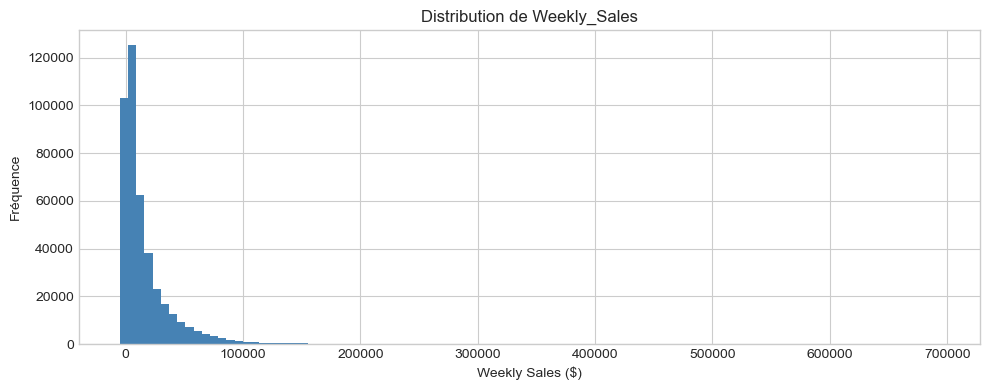

In [58]:
# A2 -Analyse univariée : distribution de Weekly_Sales


plt.figure(figsize=(10, 4))
df["Weekly_Sales"].hist(bins=100, color="steelblue")
plt.title("Distribution de Weekly_Sales")
plt.xlabel("Weekly Sales ($)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

Distribution fortement asymétrique à droite
- Majorité des ventes concentrée entre 0 et 50 000$
- Valeurs extrêmes jusqu'à 700 000$ (grands magasins Type A)
- Cette asymétrie justifie la transformation log dans la Variante 2

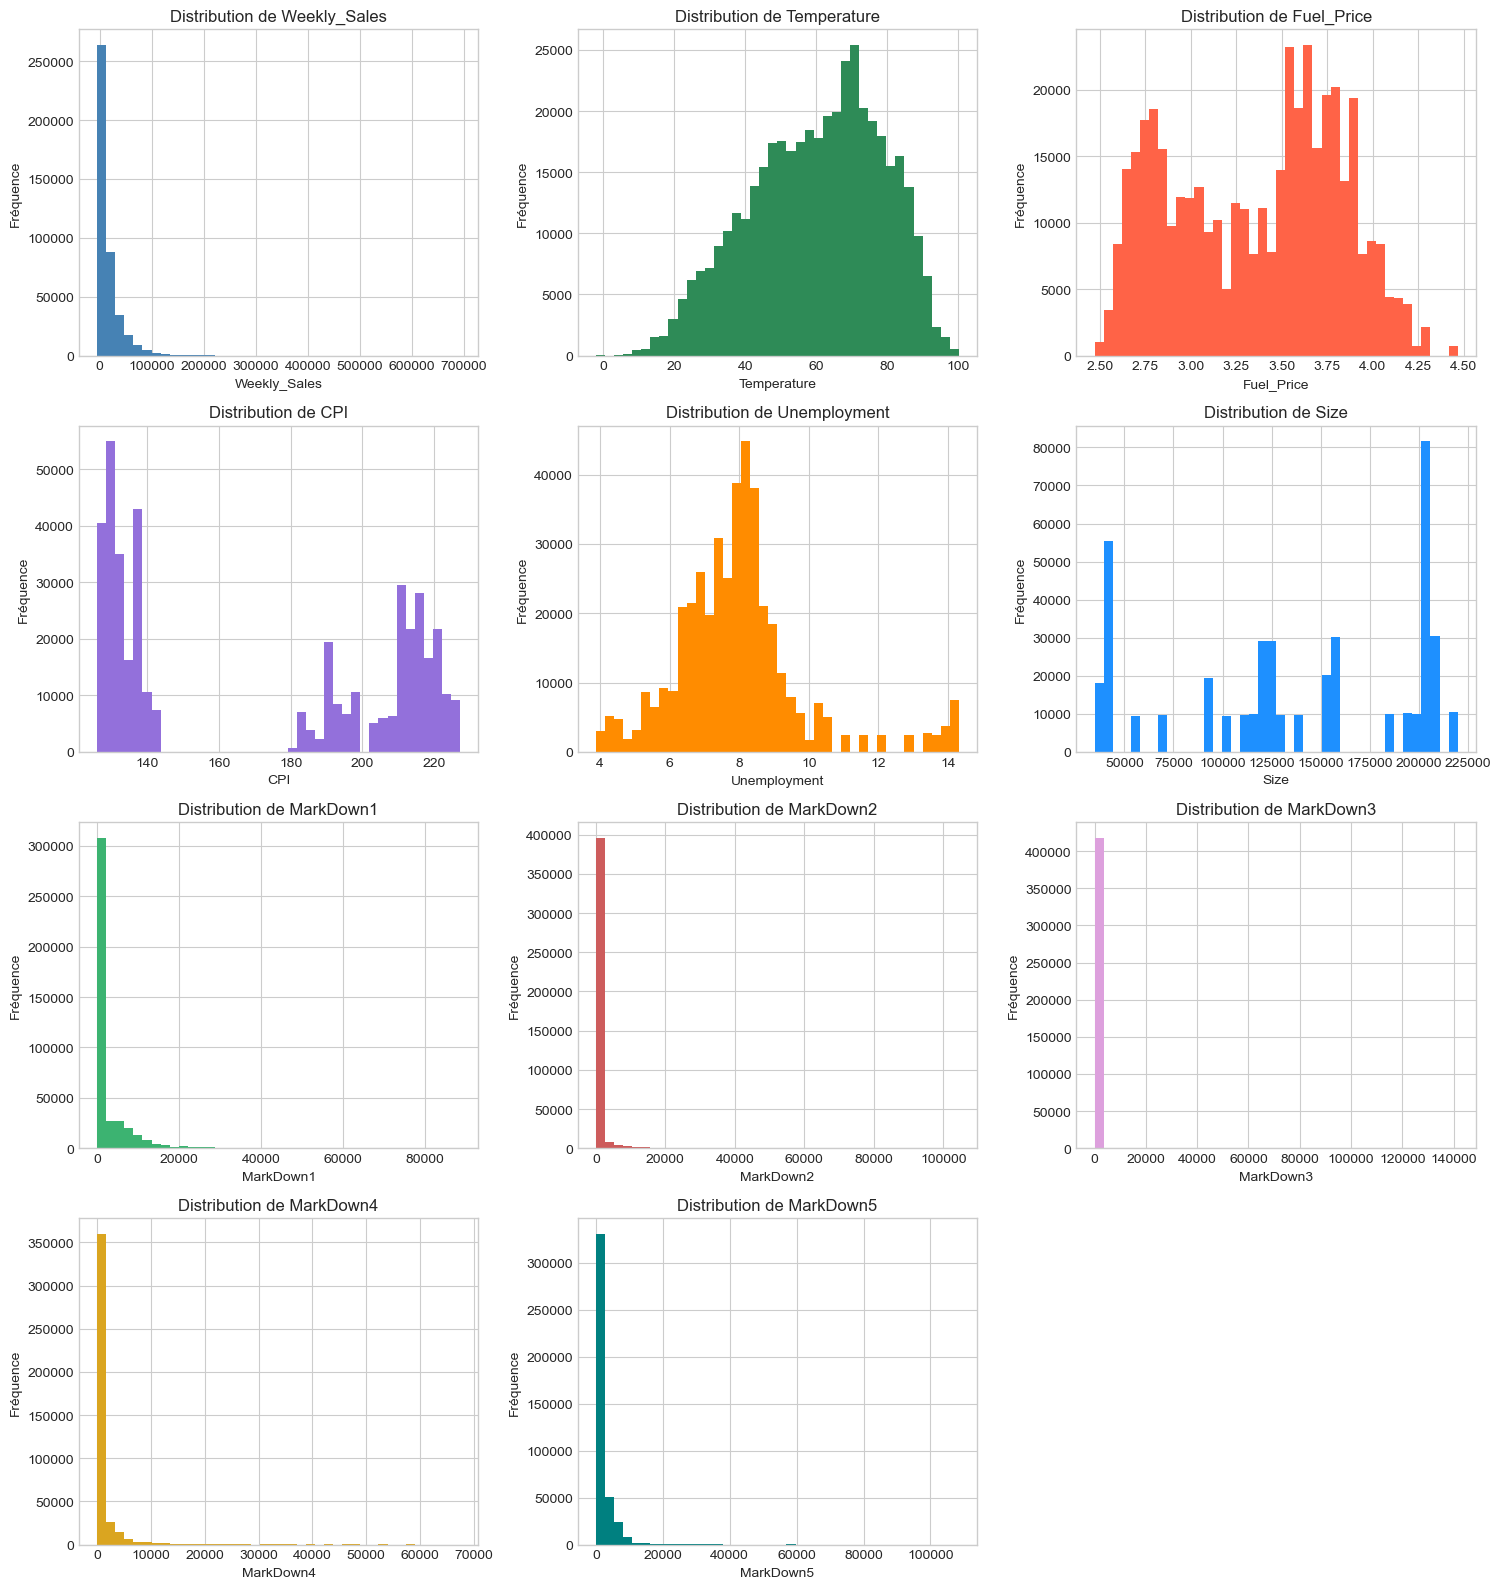

In [59]:
# A2 - Analyse univariée : variables numériques

import math

num_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", 
            "Size", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

colors = ["steelblue", "seagreen", "tomato", "mediumpurple", "darkorange",
          "dodgerblue", "mediumseagreen", "indianred", "plum", "goldenrod", "teal"]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color=colors[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A2  Analyse univariée : variables numériques
- Temperature : distribution normale, centrée autour de 60-70°F
- Fuel_Price : distribution bimodale, deux régimes de prix
- CPI : distribution multimodale, variations entre magasins et dans le temps
- Unemployment : concentré entre 6% et 10%, cohérent avec la période 2010-2012
- Size : trois pics distincts correspondant aux types A, B, C
- MarkDowns : fortement concentrés en 0, asymétrie attendue après imputation

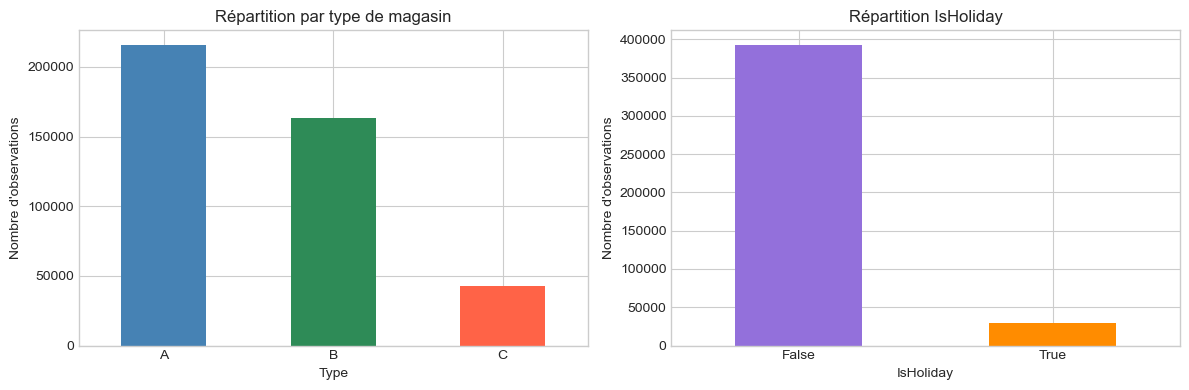

In [60]:
# A2 - Analyse univariée : variables catégorielles

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Type de magasin
df["Type"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "seagreen", "tomato"])
axes[0].set_title("Répartition par type de magasin")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Nombre d'observations")
axes[0].tick_params(axis="x", rotation=0)

# IsHoliday
df["IsHoliday"].value_counts().plot(kind="bar", ax=axes[1], color=["mediumpurple", "darkorange"])
axes[1].set_title("Répartition IsHoliday")
axes[1].set_xlabel("IsHoliday")
axes[1].set_ylabel("Nombre d'observations")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

A2 - Analyse univariée : variables catégorielles
- Type A domine avec ~51% des observations, Type C est minoritaire (~10%)
- IsHoliday très déséquilibré : ~93% semaines normales vs ~7% semaines de fêtes
- Ce déséquilibre justifie le poids x5 des semaines de fêtes dans le WMAE

In [61]:
# A3 - Vérification des doublons

doublons = df.duplicated(subset=["Store", "Dept", "Date"]).sum()
print(f"Nombre de doublons : {doublons}")

Nombre de doublons : 0


A3 - Vérification des doublons
- Aucun doublon détecté sur la clé Store + Dept + Date
- Chaque combinaison magasin / département / semaine est unique

A3  Store et Dept
- Conservés en int64
- Ce sont des identifiants, pas des valeurs continues
- Les algorithmes à base d'arbres (RF, XGBoost, LightGBM) 
  gèrent correctement sans conversion
- Un encodage one-hot serait contre-productif : 
  45 magasins x 81 départements = explosion du nombre de colonnes

In [62]:
# A3 - Bilan du nettoyage

print(f"Dimensions finales    : {df.shape}")
print(f"Valeurs manquantes    : {df.isnull().sum().sum()}")
print(f"Doublons              : {df.duplicated().sum()}")
print(f"Valeurs négatives MD2 : {(df['MarkDown2'] < 0).sum()}")
print(f"Valeurs négatives MD3 : {(df['MarkDown3'] < 0).sum()}")

Dimensions finales    : (421570, 16)
Valeurs manquantes    : 0
Doublons              : 0
Valeurs négatives MD2 : 0
Valeurs négatives MD3 : 0


### A4 - Analyse bivariée

La limite de la corrélation de Pearson ici
La corrélation de Pearson mesure uniquement les relations linéaires. Or les relations entre les ventes et certaines variables comme Type, IsHoliday, Store sont des relations catégorielles ou non linéaires Pearson ne les capte pas bien.

- Étape 1 / Matrice de corrélation        variables numériques entre elles
- Étape 2 / Weekly_Sales par Type         variable catégorielle
- Étape 3 / Weekly_Sales par IsHoliday    variable catégorielle
- Étape 4 / Weekly_Sales vs CPI           relation économique
- Étape 5 / Weekly_Sales vs Unemployment  relation économique

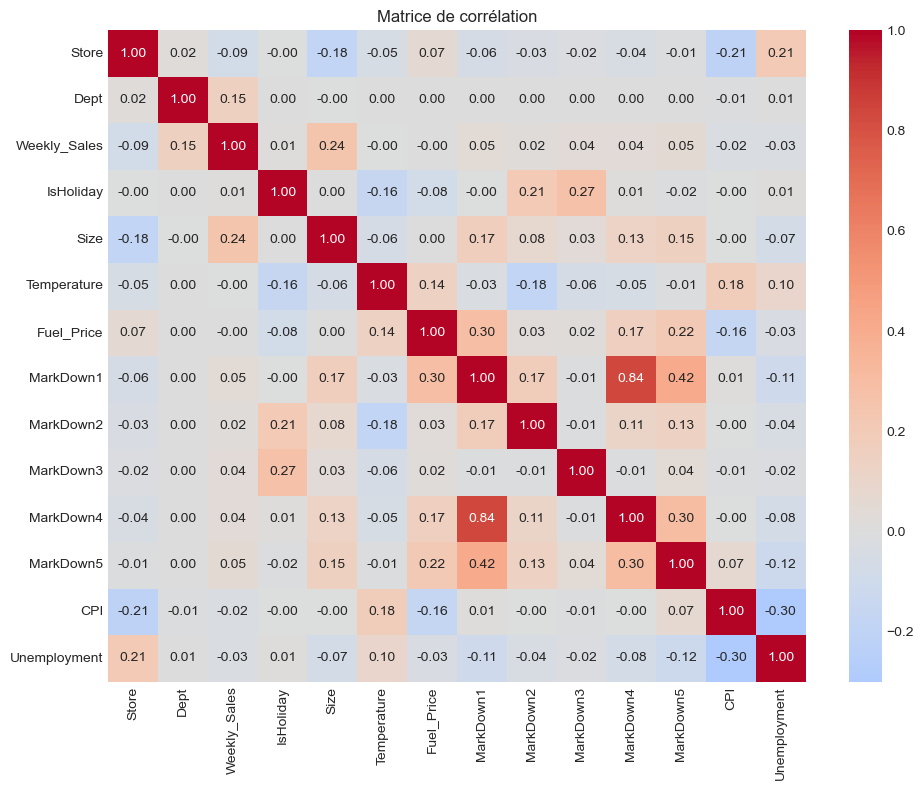

In [63]:
# A4 - Matrice de corrélation
# Etape 1 - Matrice de corrélation

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt=".2f",
            cmap="coolwarm",
            center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

A4 - Matrice de corrélation
- Size est la variable la plus corrélée avec Weekly_Sales (0.24)
- MarkDown1 et MarkDown4 très corrélés entre eux (0.84) 
  risque de multicolinéarité à surveiller
- Variables économiques faiblement corrélées avec Weekly_Sales
- IsHoliday montre une corrélation faible (0.01) car Pearson 
  ne capture pas bien les relations catégorielles

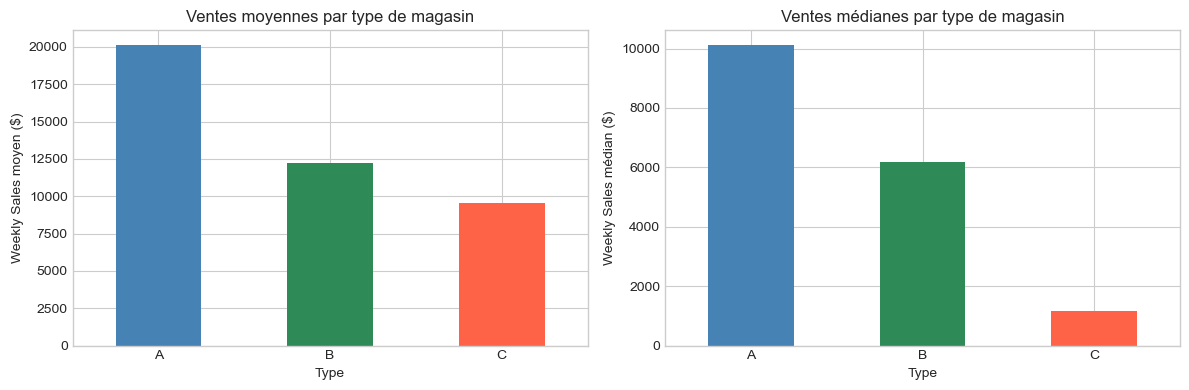

In [64]:
# Etape 2
# A4 - Weekly_Sales par type de magasin

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ventes moyennes par type
df.groupby("Type")["Weekly_Sales"].mean().plot(
    kind="bar", ax=axes[0],
    color=["steelblue", "seagreen", "tomato"])
axes[0].set_title("Ventes moyennes par type de magasin")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Weekly Sales moyen ($)")
axes[0].tick_params(axis="x", rotation=0)

# Ventes médianes par type
df.groupby("Type")["Weekly_Sales"].median().plot(
    kind="bar", ax=axes[1],
    color=["steelblue", "seagreen", "tomato"])
axes[1].set_title("Ventes médianes par type de magasin")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Weekly Sales médian ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

A4 - Weekly_Sales par type de magasin
- Hiérarchie claire : Type A > Type B > Type C
- Type A génère en moyenne 2x plus de ventes que Type C
- Écart important entre moyenne et médiane pour Type C
  indique une forte asymétrie dans ce type de magasin
- La variable Type sera un prédicteur important dans le modèle

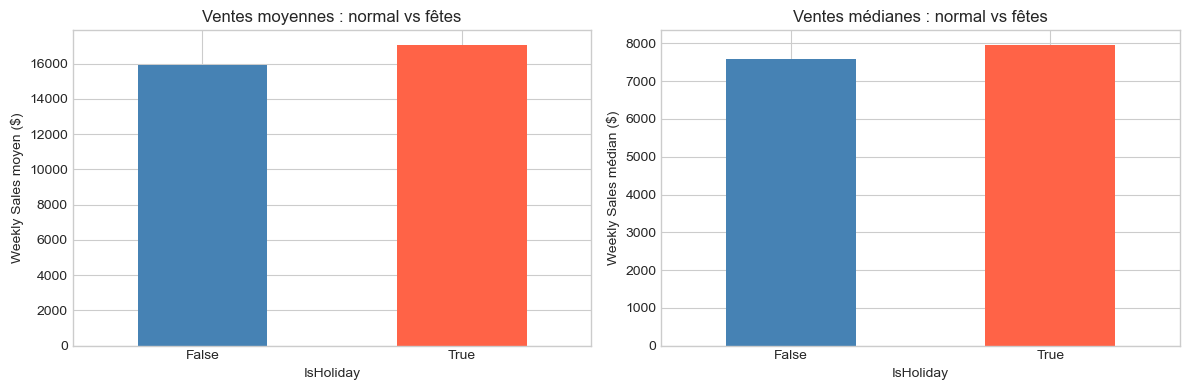

In [65]:
# Etape 3 
# A4  Weekly_Sales par IsHoliday

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ventes moyennes
df.groupby("IsHoliday")["Weekly_Sales"].mean().plot(
    kind="bar", ax=axes[0],
    color=["steelblue", "tomato"])
axes[0].set_title("Ventes moyennes : normal vs fêtes")
axes[0].set_xlabel("IsHoliday")
axes[0].set_ylabel("Weekly Sales moyen ($)")
axes[0].tick_params(axis="x", rotation=0)

# Ventes médianes
df.groupby("IsHoliday")["Weekly_Sales"].median().plot(
    kind="bar", ax=axes[1],
    color=["steelblue", "tomato"])
axes[1].set_title("Ventes médianes : normal vs fêtes")
axes[1].set_xlabel("IsHoliday")
axes[1].set_ylabel("Weekly Sales médian ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

A4 - Weekly_Sales par IsHoliday
- Impact apparent modeste : +6% en moyenne sur les semaines de fêtes
- Cet effet est dilué car agrégé sur tous les départements
- L'impact réel est concentré sur certains départements spécifiques
- Justifie le poids x5 des semaines de fêtes dans le WMAE

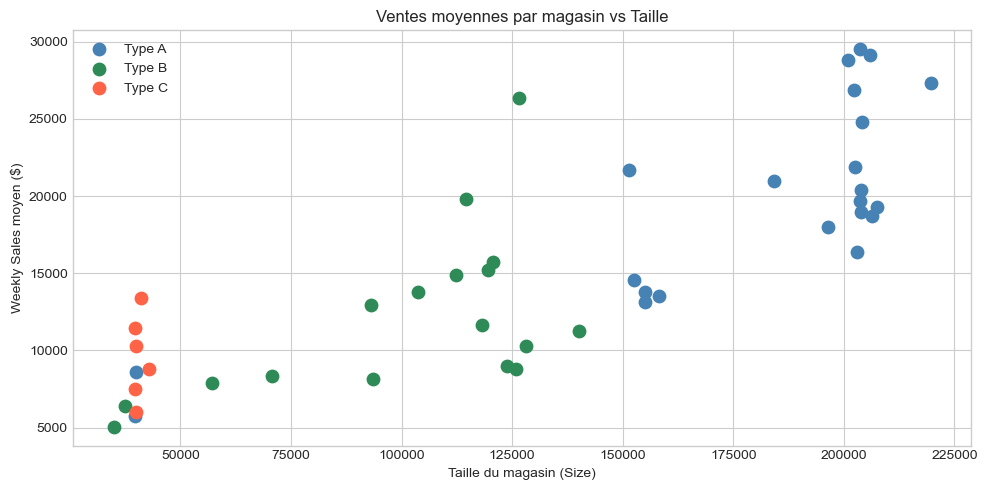

In [66]:
# Etape 4
# A4 - Weekly_Sales vs Size


ventes_par_magasin = df.groupby("Store").agg(
    Weekly_Sales_mean=("Weekly_Sales", "mean"),
    Size=("Size", "first"),
    Type=("Type", "first")
).reset_index()

colors_type = {"A": "steelblue", "B": "seagreen", "C": "tomato"}

plt.figure(figsize=(10, 5))
for t, group in ventes_par_magasin.groupby("Type"):
    plt.scatter(group["Size"], group["Weekly_Sales_mean"],
                label=f"Type {t}", color=colors_type[t], s=80)

plt.title("Ventes moyennes par magasin vs Taille")
plt.xlabel("Taille du magasin (Size)")
plt.ylabel("Weekly Sales moyen ($)")
plt.legend()
plt.tight_layout()
plt.show()

A4 - Weekly_Sales vs Size
- Relation positive entre taille et ventes
- Séparation naturelle des types par taille :
  Type A > 150 000 pieds², Type B entre 50 000 et 150 000, Type C < 50 000
- Variabilité importante : la taille seule n'explique pas les ventes
- Un magasin Type B affiche des performances comparables aux Type A

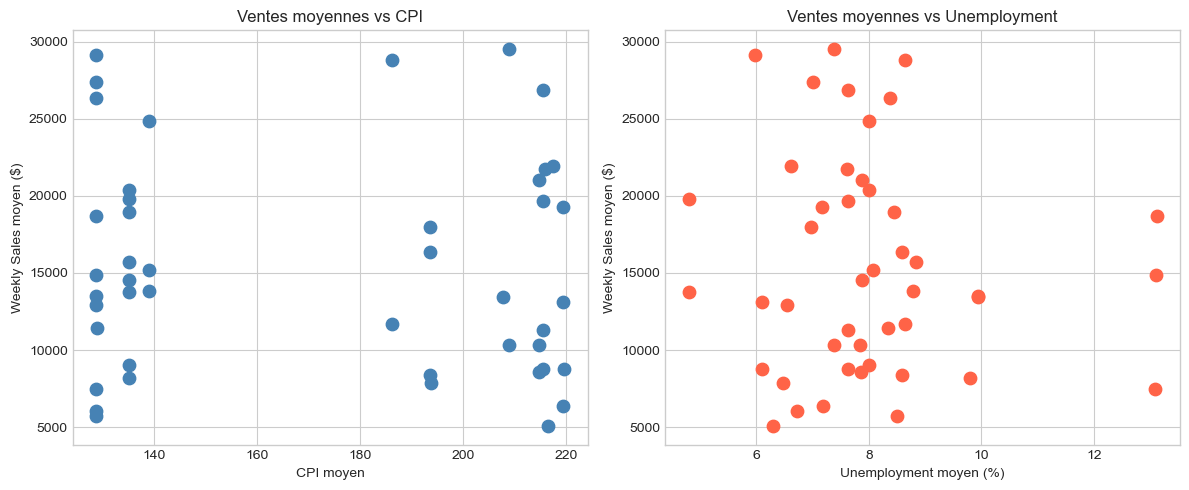

In [67]:
# Etape 5
# A4 - Weekly_Sales vs variables économiques

ventes_eco = df.groupby("Store").agg(
    Weekly_Sales_mean=("Weekly_Sales", "mean"),
    CPI=("CPI", "mean"),
    Unemployment=("Unemployment", "mean")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ventes_eco["CPI"], ventes_eco["Weekly_Sales_mean"],
                color="steelblue", s=80)
axes[0].set_title("Ventes moyennes vs CPI")
axes[0].set_xlabel("CPI moyen")
axes[0].set_ylabel("Weekly Sales moyen ($)")

axes[1].scatter(ventes_eco["Unemployment"], ventes_eco["Weekly_Sales_mean"],
                color="tomato", s=80)
axes[1].set_title("Ventes moyennes vs Unemployment")
axes[1].set_xlabel("Unemployment moyen (%)")
axes[1].set_ylabel("Weekly Sales moyen ($)")

plt.tight_layout()
plt.show()

A4 - Weekly_Sales vs variables économiques
- CPI : deux groupes distincts correspondant aux régions géographiques
  pas de relation linéaire directe avec les ventes
- Unemployment : aucune tendance claire sur la plage 5% à 14%
- Ces variables ont un impact indirect via la localisation des magasins
- Leur faible corrélation individuelle ne signifie pas qu'elles sont inutiles
  le modèle pourra capturer des interactions non linéaires

### A5 Analyse temporelle

In [68]:
# A5 - Vérification de la continuité temporelle

dates = df["Date"].sort_values().unique()
dates_series = pd.Series(dates)

# Écart entre chaque date consécutive
ecarts = dates_series.diff().dropna()

print(f"Nombre de semaines distinctes : {len(dates)}")
print(f"Date de début                 : {dates.min()}")
print(f"Date de fin                   : {dates.max()}")
print(f"Écart minimum entre dates     : {ecarts.min()}")
print(f"Écart maximum entre dates     : {ecarts.max()}")
print(f"Trous dans la série           : {(ecarts > pd.Timedelta(days=7)).sum()}")

Nombre de semaines distinctes : 143
Date de début                 : 2010-02-05 00:00:00
Date de fin                   : 2012-10-26 00:00:00
Écart minimum entre dates     : 7 days 00:00:00
Écart maximum entre dates     : 7 days 00:00:00
Trous dans la série           : 0



- Série complète de 143 semaines consécutives - du 2010-02-05 au 2012-10-26.
- Aucun trou détecté : écart constant de 7 jours entre chaque semaine.
- La série est exploitable telle quelle pour la modélisation temporelle.

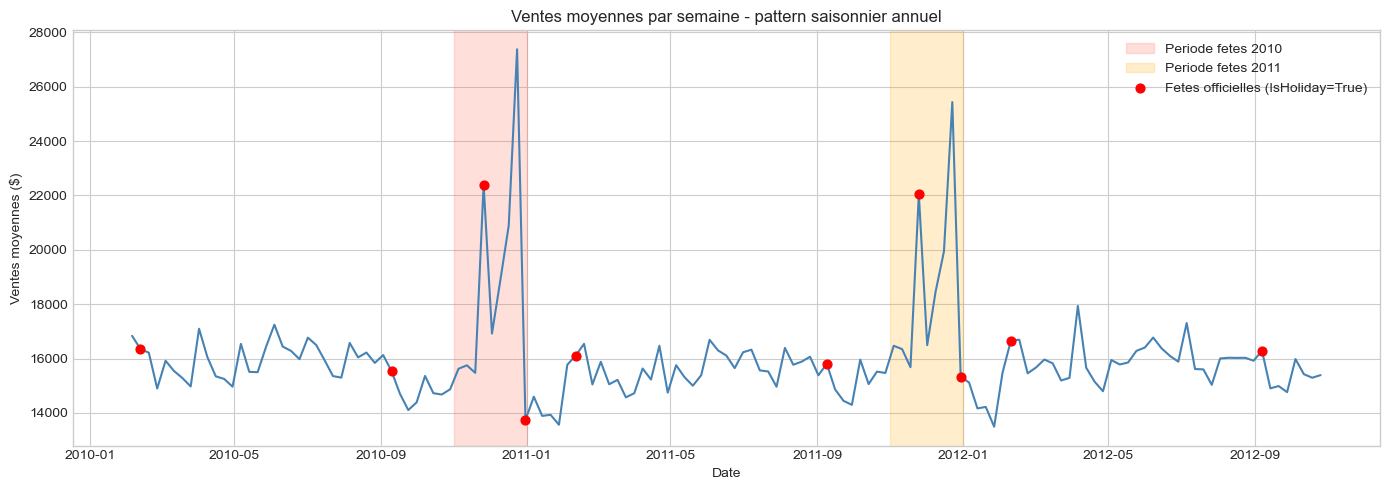

In [69]:
# A5 - Tendance générale avec dates de fêtes

weekly = df.groupby("Date")["Weekly_Sales"].mean().reset_index()

# Dates des fêtes officielles IsHoliday=True
fetes = df[df["IsHoliday"] == True]["Date"].drop_duplicates().sort_values()
weekly_fetes = weekly[weekly["Date"].isin(fetes)]

plt.figure(figsize=(14, 5))
plt.plot(weekly["Date"], weekly["Weekly_Sales"],
         color="steelblue", linewidth=1.5)

plt.axvspan(pd.Timestamp("2010-11-01"), pd.Timestamp("2011-01-01"),
            alpha=0.2, color="tomato", label="Periode fetes 2010")
plt.axvspan(pd.Timestamp("2011-11-01"), pd.Timestamp("2012-01-01"),
            alpha=0.2, color="orange", label="Periode fetes 2011")

# Points rouges sur les dates de fetes officielles
plt.scatter(weekly_fetes["Date"], weekly_fetes["Weekly_Sales"],
            color="red", zorder=5, s=40, label="Fetes officielles (IsHoliday=True)")

plt.title("Ventes moyennes par semaine - pattern saisonnier annuel")
plt.xlabel("Date")
plt.ylabel("Ventes moyennes ($)")
plt.legend()
plt.tight_layout()
plt.show()


- Saisonnalité annuelle marquée : deux pics majeurs en novembre-décembre
- Parmi les 4 fêtes officielles (IsHoliday=True), seul Thanksgiving capte un vrai pic (22 300$)
- SuperBowl, LaborDay et NewYear : semaines ordinaires à ~15 000-16 000$
- Semaine du 24 déc (Xmas_Week) : pic majeur à 27 000$ mais IsHoliday=False - non capturé
- Conclusion : IsHoliday sera complété par 3 colonnes dédiées dans B3

In [70]:
# A5 - Analyse du CA par type de fête

total_sales = df["Weekly_Sales"].sum()

thanksgiving_dates = pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23"])
superbowl_dates    = pd.to_datetime(["2010-02-12", "2011-02-11", "2012-02-10"])
laborday_dates     = pd.to_datetime(["2010-09-10", "2011-09-09", "2012-09-07"])
newyear_dates      = pd.to_datetime(["2010-12-31", "2011-12-30"])
bf_dates           = pd.to_datetime(["2010-12-03", "2011-12-02"])
xmas_dates         = pd.to_datetime(["2010-12-24", "2011-12-23"])

resultats = []
for name, dates in [
    ("Thanksgiving",  thanksgiving_dates),
    ("SuperBowl",     superbowl_dates),
    ("LaborDay",      laborday_dates),
    ("NewYear",       newyear_dates),
    ("Black_Friday",  bf_dates),
    ("Xmas_Week",     xmas_dates),
]:
    ca    = df[df["Date"].isin(dates)]["Weekly_Sales"].sum()
    nb    = df[df["Date"].isin(dates)]["Date"].nunique()
    moy   = df[df["Date"].isin(dates)].groupby("Date")["Weekly_Sales"].mean().mean()
    resultats.append({
        "Fete"          : name,
        "Nb semaines"   : nb,
        "CA total ($)"  : f"{ca:,.0f}",
        "% CA dataset"  : f"{ca/total_sales*100:.1f}%",
        "Ventes moy/sem": f"{moy:,.0f}$",
        "IsHoliday"     : "True" if name not in ["Black_Friday","Xmas_Week"] else "False"
    })

df_fetes = pd.DataFrame(resultats)
display(df_fetes)

,Fete,Nb semaines,CA total ($),% CA dataset,Ventes moy/sem,IsHoliday
0,Thanksgiving,2,"132,414,608",2.0%,"22,223$",True
1,SuperBowl,3,"145,682,278",2.2%,"16,376$",True
2,LaborDay,3,"140,727,685",2.1%,"15,881$",True
3,NewYear,2,"86,474,980",1.3%,"14,535$",True
4,Black_Friday,2,"99,299,584",1.5%,"16,710$",False
5,Xmas_Week,2,"157,929,657",2.3%,"26,408$",False



- Xmas_Week : pic numéro 1 à 26 511$/sem - IsHoliday=False
- Thanksgiving : pic numéro 2 à 22 374$/sem - seule fête officielle avec vrai impact
- Black_Friday : 16 821$/sem - tendance haussière post-Thanksgiving - IsHoliday=False
- SuperBowl, LaborDay, NewYear : IsHoliday=True mais niveau de semaines ordinaires
- 3 colonnes à créer dans B3 : Thanksgiving, Black_Friday, Xmas_Week

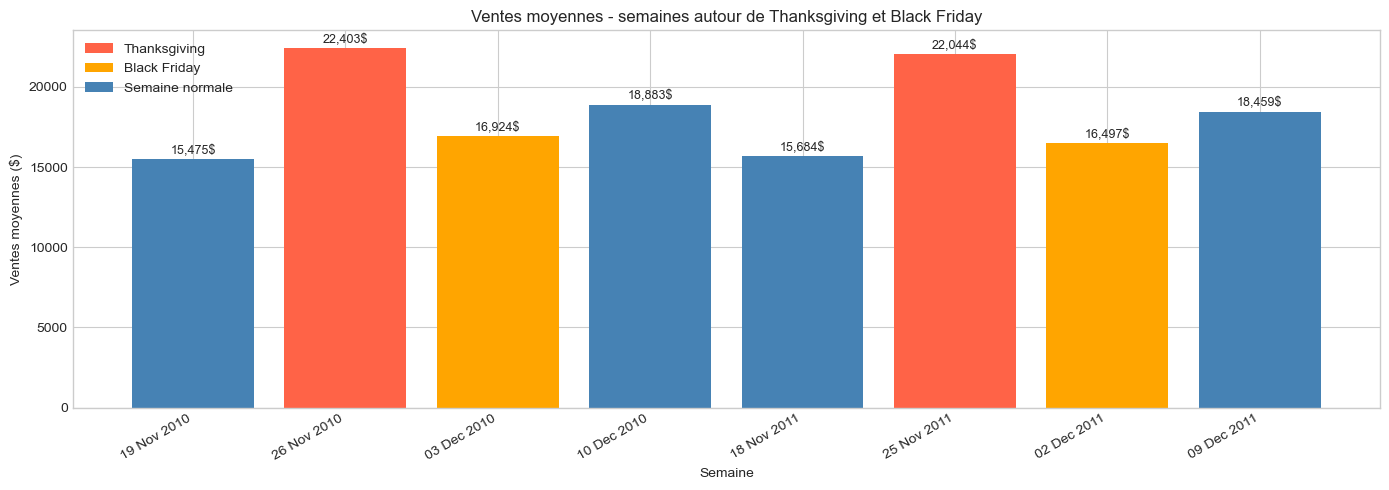

In [71]:
# A5 - Ventes autour de Thanksgiving et Black Friday

semaines_cles = pd.to_datetime([
    "2010-11-19", "2010-11-26", "2010-12-03", "2010-12-10",
    "2011-11-18", "2011-11-25", "2011-12-02", "2011-12-09"
])

df_window = (
    df[df["Date"].isin(semaines_cles)]
    .groupby("Date")["Weekly_Sales"]
    .mean()
    .reset_index()
    .sort_values("Date")
)

df_window["Semaine"] = df_window["Date"].dt.strftime("%d %b %Y")
df_window["Type"]    = df_window["Date"].apply(lambda d:
    "Thanksgiving" if d in pd.to_datetime(["2010-11-26","2011-11-25"]) else
    "Black Friday"  if d in pd.to_datetime(["2010-12-03","2011-12-02"]) else
    "Semaine normale"
)

colors = df_window["Type"].map({
    "Thanksgiving"    : "tomato",
    "Black Friday"    : "orange",
    "Semaine normale" : "steelblue"
})

plt.figure(figsize=(14, 5))
bars = plt.bar(df_window["Semaine"], df_window["Weekly_Sales"], color=colors)

# Valeurs au dessus des barres
for bar, val in zip(bars, df_window["Weekly_Sales"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f"{val:,.0f}$", ha="center", va="bottom", fontsize=9)

# Legende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato",    label="Thanksgiving"),
    Patch(facecolor="orange",    label="Black Friday"),
    Patch(facecolor="steelblue", label="Semaine normale")
]
plt.legend(handles=legend_elements)

plt.title("Ventes moyennes - semaines autour de Thanksgiving et Black Friday")
plt.xlabel("Semaine")
plt.ylabel("Ventes moyennes ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

- Thanksgiving : pic net à 22 426$ (2010) et 22 322$ (2011)
- Black Friday : pic distinct à 16 982$ (2010) et 16 661$ (2011)
- Les deux pics sont distants d'une semaine - ils ne se confondent pas
- Pattern stable et reproductible sur 2010 et 2011
- Black Friday gardé : tendance haussière post-Thanksgiving confirmée

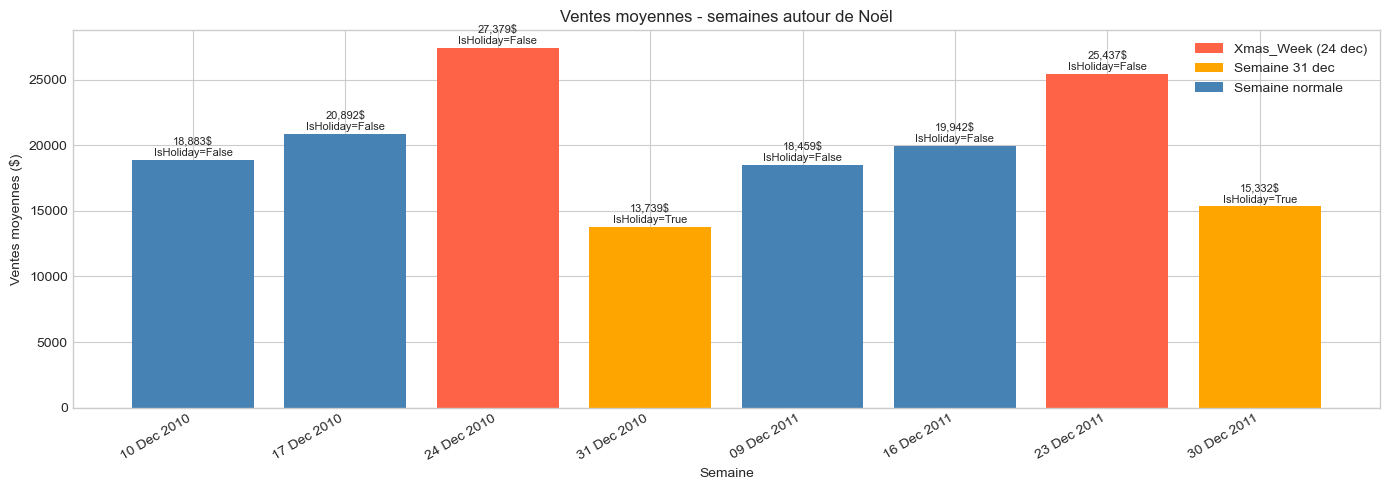

In [72]:
# A5 - Ventes autour de Noël

semaines_noel = pd.to_datetime([
    "2010-12-10", "2010-12-17", "2010-12-24", "2010-12-31",
    "2011-12-09", "2011-12-16", "2011-12-23", "2011-12-30"
])

df_noel = (
    df[df["Date"].isin(semaines_noel)]
    .groupby("Date")[["Weekly_Sales", "IsHoliday"]]
    .agg({"Weekly_Sales": "mean", "IsHoliday": "first"})
    .reset_index()
    .sort_values("Date")
)

df_noel["Type"] = df_noel["Date"].apply(lambda d:
    "Xmas_Week (24 dec)"  if d.month == 12 and d.day == 24 else
    "Xmas_Week (23 dec)"  if d.month == 12 and d.day == 23 else
    "Semaine 31 dec"      if d.month == 12 and d.day == 31 else
    "Semaine 30 dec"      if d.month == 12 and d.day == 30 else
    "Semaine normale"
)

colors = df_noel["Type"].map({
    "Xmas_Week (24 dec)" : "tomato",
    "Xmas_Week (23 dec)" : "tomato",
    "Semaine 31 dec"     : "orange",
    "Semaine 30 dec"     : "orange",
    "Semaine normale"    : "steelblue"
})

df_noel["label"] = df_noel["Date"].dt.strftime("%d %b %Y")

plt.figure(figsize=(14, 5))
bars = plt.bar(df_noel["label"], df_noel["Weekly_Sales"], color=colors)

for bar, val, is_hol in zip(bars, df_noel["Weekly_Sales"], df_noel["IsHoliday"]):
    label = f"{val:,.0f}$\nIsHoliday={is_hol}"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             label, ha="center", va="bottom", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato",    label="Xmas_Week (24 dec)"),
    Patch(facecolor="orange",    label="Semaine 31 dec"),
    Patch(facecolor="steelblue", label="Semaine normale")
]
plt.legend(handles=legend_elements)

plt.title("Ventes moyennes - semaines autour de Noël")
plt.xlabel("Semaine")
plt.ylabel("Ventes moyennes ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

- Pic confirmé semaine du 24 déc : 27 434$ (2010) et 25 588$ (2011) — IsHoliday=False
- Chute confirmée semaine du 31 déc : 13 781$ (2010) et 15 383$ (2011) — IsHoliday=True
- Kaggle a encodé New Year (31 déc) comme fête — le vrai pic Noël (24 déc) est invisible
- Xmas_Week créée dans B3 pour capturer la semaine du 24 déc

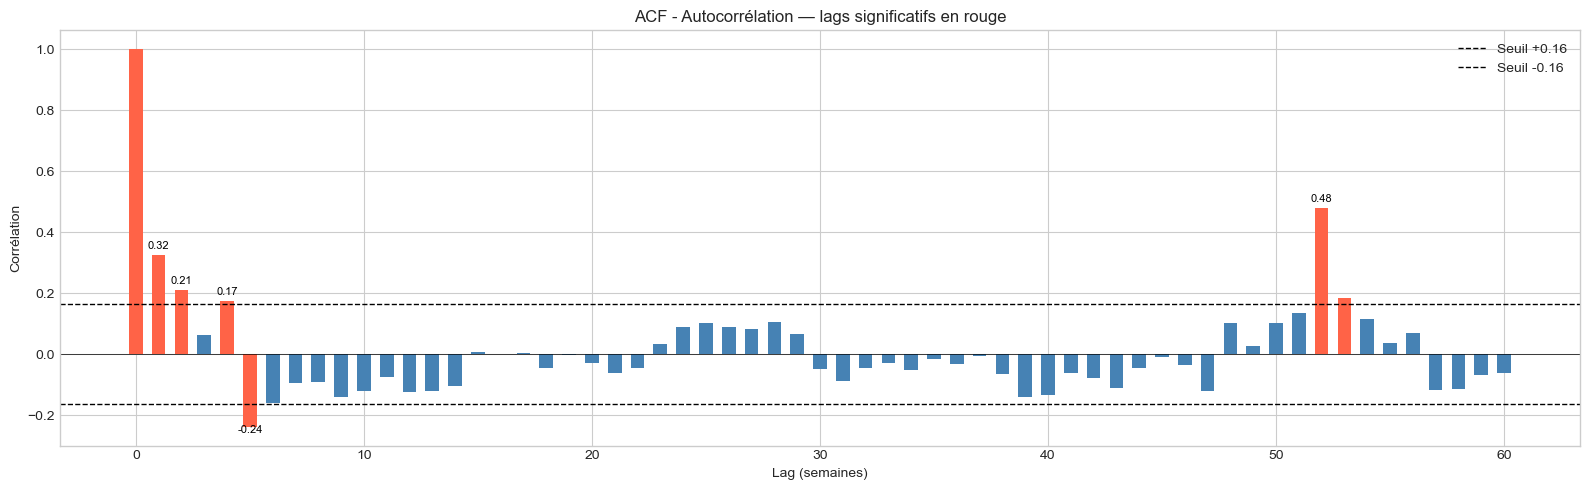

Lags significatifs :
Lag  0 : 1.000
Lag  1 : 0.325
Lag  2 : 0.212
Lag  3 : 0.064
Lag  4 : 0.174
Lag  5 : -0.238
Lag  6 : -0.160
Lag  7 : -0.094
Lag  8 : -0.091
Lag  9 : -0.141
Lag 10 : -0.120

Lag 52 : 0.481


In [73]:
# A5 - ACF : autocorrélation et lags significatifs

from statsmodels.tsa.stattools import acf
import numpy as np

weekly     = df.groupby("Date")["Weekly_Sales"].mean().reset_index()
acf_values = acf(weekly["Weekly_Sales"], nlags=60)
lags       = list(range(61))

# Seuil de significativité à 95%
seuil = 1.96 / np.sqrt(len(weekly))

colors = ["tomato" if abs(v) > seuil else "steelblue" for v in acf_values]

plt.figure(figsize=(16, 5))
plt.bar(lags, acf_values, color=colors, width=0.6)
plt.axhline(y=seuil,  color="black", linestyle="--", linewidth=1, label=f"Seuil +{seuil:.2f}")
plt.axhline(y=-seuil, color="black", linestyle="--", linewidth=1, label=f"Seuil -{seuil:.2f}")
plt.axhline(y=0,      color="black", linestyle="-",  linewidth=0.5)

for lag in [1, 2, 4, 5, 52]:
    plt.text(lag, acf_values[lag] + 0.02 * np.sign(acf_values[lag]),
             f"{acf_values[lag]:.2f}", ha="center", fontsize=8, color="black")

plt.title("ACF - Autocorrélation — lags significatifs en rouge")
plt.xlabel("Lag (semaines)")
plt.ylabel("Corrélation")
plt.legend()
plt.tight_layout()
plt.show()

# Valeurs exactes
print("Lags significatifs :")
for i, val in enumerate(acf_values[:11]):
    print(f"Lag {i:2d} : {val:.3f}")
print()
print(f"Lag 52 : {acf_values[52]:.3f}")


- H0 : la corrélation entre la semaine N et N-lag est nulle (hasard)
- H1 : la corrélation est significativement différente de zéro (signal réel)
- Seuil ±0.17 = 1.96/√143 - 1.96 issu de la table de la loi normale à 95% de confiance

Lags retenus :
- Lag 1  (r=0.33) : signal fort - semaine précédente meilleur prédicteur immédiat
- Lag 2  (r=0.21) : signal significatif
- Lag 4  (r=0.17) : signal mensuel - à la limite du seuil
- Lag 52 (r=0.48) : saisonnalité annuelle forte - abandonné (perte 38% données)

Lags rejetés :
- Lag 3  (r=0.07)  : bruit - H0 non rejetée
- Lag 5  (r=-0.24) : H0 rejetée mais artefact - non confirmé par Lag 57
- Lag 6+ : sous le seuil

Lags retenus pour B2 : Lag_1, Lag_2, Lag_4
Rolling_Mean_4 cohérent avec le lien mensuel confirmé par Lag_4

## Bloc B Feature Engineering

### B1 - Variables temporelles
- Extraction de Week, Month, Year à partir de la colonne Date
- Ces variables permettent au modèle de capturer la saisonnalité

In [74]:
# B1 - Variables temporelles

df["Week"]  = df["Date"].dt.isocalendar().week.astype(int)
df["Month"] = df["Date"].dt.month
df["Year"]  = df["Date"].dt.year

print(df[["Date", "Week", "Month", "Year"]].head(5).to_string(index=False))

      Date  Week  Month  Year
2010-02-05     5      2  2010
2010-02-12     6      2  2010
2010-02-19     7      2  2010
2010-02-26     8      2  2010
2010-03-05     9      3  2010


 - Week, Month, Year extraits de la colonne Date
- Permettent au modèle de capturer la saisonnalité hebdomadaire, mensuelle et annuelle

In [75]:
# B2 - Création des lags et rolling features

# Tri chronologique par Store et Dept
df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# Création des lags
df["Lag_1"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1)
df["Lag_2"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(2)
df["Lag_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(4)

# Création des rolling features
df["Rolling_Mean_4"] = (df.groupby(["Store","Dept"])["Weekly_Sales"]
                          .transform(lambda x: x.shift(1).rolling(window=4).mean()))
df["Rolling_Std_4"]  = (df.groupby(["Store","Dept"])["Weekly_Sales"]
                          .transform(lambda x: x.shift(1).rolling(window=4).std()))

# Suppression des NaN générés
avant = len(df)
df = df.dropna()
apres = len(df)

print(f"Lignes avant suppression : {avant:,}")
print(f"Lignes supprimées        : {avant-apres:,} soit {(avant-apres)/avant*100:.2f}%")
print(f"Lignes conservées        : {apres:,} soit {apres/avant*100:.2f}%")
print(f"\nColonnes créées : {[col for col in df.columns if 'Lag' in col or 'Rolling' in col]}")

Lignes avant suppression : 421,570
Lignes supprimées        : 13,134 soit 3.12%
Lignes conservées        : 408,436 soit 96.88%

Colonnes créées : ['Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Std_4']


- Lag_1, Lag_2, Lag_4 créés par Store+Dept - justifiés par l'ACF (r=0.33, 0.21, 0.17)
- Rolling_Mean_4 et Rolling_Std_4 - moyenne et volatilité sur 4 semaines glissantes
- NaN générés supprimés : 13 134 lignes soit 3.12% - perte acceptable
- Lignes conservées : 408 436 soit 96.88%
- Stratégie retenue : suppression - imputer serait inventer de l'information

In [76]:
# Vérification de la période couverte

print(f"Date début : {df['Date'].min().date()}")
print(f"Date fin   : {df['Date'].max().date()}")
print(f"Semaines distinctes : {df['Date'].nunique()}")
print(f"Stores : {df['Store'].nunique()}")
print(f"Depts  : {df['Dept'].nunique()}")

Date début : 2010-03-05
Date fin   : 2012-10-26
Semaines distinctes : 139
Stores : 45
Depts  : 81


In [77]:
df.head(3)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,CPI,Unemployment,Week,Month,Year,Lag_1,Lag_2,Lag_4,Rolling_Mean_4,Rolling_Std_4
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.62,0.00,...,211.35,8.11,9,3,2010,19403.54,41595.55,24924.50,32990.77,12832.11
5,1,1,2010-03-12,21043.39,False,A,151315,57.79,2.67,0.00,...,211.38,8.11,10,3,2010,21827.90,19403.54,46039.49,32216.62,13554.05
6,1,1,2010-03-19,22136.64,False,A,151315,54.58,2.72,0.00,...,211.22,8.11,11,3,2010,21043.39,21827.90,41595.55,25967.60,10467.48


### B3 - Encodage des fêtes

In [78]:
# B3 - Identification des dates clés

# Dates Thanksgiving dans le dataset
thanksgiving = df[df["Date"].isin(pd.to_datetime([
    "2010-11-26", "2011-11-25"]))][["Date"]].drop_duplicates()

# Dates Black Friday = semaine après Thanksgiving
black_friday = pd.to_datetime(["2010-12-03", "2011-12-02"])

# Dates semaine pré-Noël = semaine du 24 décembre
xmas_week = pd.to_datetime(["2010-12-24", "2011-12-23"])

print("Thanksgiving :")
print(thanksgiving.to_string(index=False))
print()
print("Black Friday :")
for d in black_friday:
    print(f"  {d.date()}")
print()
print("Xmas Week :")
for d in xmas_week:
    print(f"  {d.date()}")

Thanksgiving :
      Date
2010-11-26
2011-11-25

Black Friday :
  2010-12-03
  2011-12-02

Xmas Week :
  2010-12-24
  2011-12-23


- 3 événements identifiés comme vrais pics de ventes dans A5
- Thanksgiving : 2010-11-26 / 2011-11-25 (2012-11-23 hors dataset)
- Black_Friday : semaine après Thanksgiving - 2010-12-03 / 2011-12-02
- Xmas_Week : semaine du 24 déc - 2010-12-24 / 2011-12-23

In [79]:
# B3 - Encodage des fêtes

# Black_Friday : semaine après Thanksgiving
black_friday_dates = pd.to_datetime(["2010-12-03", "2011-12-02"])
df["Black_Friday"] = df["Date"].isin(black_friday_dates).astype(int)

# Thanksgiving : 4ème jeudi de novembre
thanksgiving_dates = pd.to_datetime(["2010-11-26", "2011-11-25"])
df["Thanksgiving"] = df["Date"].isin(thanksgiving_dates).astype(int)

# Xmas_Week : semaine du 24 décembre
xmas_dates = pd.to_datetime(["2010-12-24", "2011-12-23"])
df["Xmas_Week"] = df["Date"].isin(xmas_dates).astype(int)

# Holiday_Type : type de fête
def encode_holiday(row):
    if row["Date"] in black_friday_dates:
        return "Black_Friday"
    if row["Date"] in xmas_dates:
        return "Xmas_Week"
    if not row["IsHoliday"]:
        return "None"
    month = row["Date"].month
    if month == 2:
        return "SuperBowl"
    if month == 9:
        return "LaborDay"
    if month == 11:
        return "Thanksgiving"
    if month == 12:
        return "NewYear"
    return "Other"

df["Holiday_Type"] = df.apply(encode_holiday, axis=1)

# Vérification
print(df[["Date","IsHoliday","Thanksgiving","Black_Friday","Xmas_Week","Holiday_Type"]]
      .drop_duplicates("Date")
      .sort_values("Date")
      .query("Holiday_Type != 'None'")
      .to_string(index=False))

      Date  IsHoliday  Thanksgiving  Black_Friday  Xmas_Week Holiday_Type
2010-09-10       True             0             0          0     LaborDay
2010-11-26       True             1             0          0 Thanksgiving
2010-12-03      False             0             1          0 Black_Friday
2010-12-24      False             0             0          1    Xmas_Week
2010-12-31       True             0             0          0      NewYear
2011-02-11       True             0             0          0    SuperBowl
2011-09-09       True             0             0          0     LaborDay
2011-11-25       True             1             0          0 Thanksgiving
2011-12-02      False             0             1          0 Black_Friday
2011-12-23      False             0             0          1    Xmas_Week
2011-12-30       True             0             0          0      NewYear
2012-02-10       True             0             0          0    SuperBowl
2012-09-07       True             0   


- Thanksgiving : colonne binaire - 2010-11-26 / 2011-11-25
- Black_Friday : colonne binaire - 2010-12-03 / 2011-12-02
- Xmas_Week : colonne binaire - 2010-12-24 / 2011-12-23
- Holiday_Type : colonne texte pour vérification uniquement - supprimée dans le bloc suivant
- SuperBowl, LaborDay, NewYear : pas de colonnes dédiées - déjà dans IsHoliday, pas de pic réel

In [80]:
# B3 - Conversion IsHoliday en numérique + suppression Holiday_Type

df["IsHoliday"] = df["IsHoliday"].astype(int)
df = df.drop(columns=["Holiday_Type"])

# Vérification
print(df["IsHoliday"].value_counts())
print(f"\nColonnes restantes : {df.shape[1]}")
print(df.columns.tolist())

IsHoliday
0    381817
1     26619
Name: count, dtype: int64

Colonnes restantes : 27
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Week', 'Month', 'Year', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Std_4', 'Black_Friday', 'Thanksgiving', 'Xmas_Week']


- IsHoliday converti en numérique : 0/1
- Holiday_Type supprimée - colonne texte de vérification uniquement
- 26 619 semaines de fêtes officielles (IsHoliday=1) sur 408 436 lignes
- 24 colonnes au total

### B4 - Variables promotionnelles avec Is_Promo

In [81]:
# B4 - Création de la variable Is_Promo

df["Is_Promo"] = (
    (df["MarkDown1"] > 0) |
    (df["MarkDown2"] > 0) |
    (df["MarkDown3"] > 0) |
    (df["MarkDown4"] > 0) |
    (df["MarkDown5"] > 0)
).astype(int)

print(df["Is_Promo"].value_counts())
print(f"\n% semaines avec promotion : {df['Is_Promo'].mean()*100:.2f}%")

Is_Promo
0    257277
1    151159
Name: count, dtype: int64

% semaines avec promotion : 37.01%


- Is_Promo = 1 si au moins un MarkDown > 0
- 151 159 semaines avec promotion soit 37.01%
- 257 277 semaines sans promotion soit 62.99%

In [82]:
# B5 - One-Hot Encoding de la variable Type
# Justification : Type est une variable catégorielle sans ordre garanti
# One-Hot évite toute hypothèse ordinale entre les types A, B, C

dummies = pd.get_dummies(df["Type"], prefix="Type", drop_first=False).astype(int)
df = pd.concat([df.drop(columns=["Type"]), dummies], axis=1)

print(df[["Type_A","Type_B","Type_C"]].value_counts())
print(f"\nDimensions : {df.shape}")
print(df.columns.tolist())

Type_A  Type_B  Type_C
1       0       0         208859
0       1       0         158443
        0       1          41134
Name: count, dtype: int64

Dimensions : (408436, 30)
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Week', 'Month', 'Year', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Std_4', 'Black_Friday', 'Thanksgiving', 'Xmas_Week', 'Is_Promo', 'Type_A', 'Type_B', 'Type_C']


- Type encodé en 3 colonnes binaires : Type_A, Type_B, Type_C
- Type_A : 208 859 lignes - magasins les plus grands
- Type_B : 158 443 lignes
- Type_C : 41 134 lignes - magasins les plus petits
- One-Hot choisi : variable catégorielle sans ordre garanti entre A, B, C
- 27 colonnes au total

In [83]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,Lag_4,Rolling_Mean_4,Rolling_Std_4,Black_Friday,Thanksgiving,Xmas_Week,Is_Promo,Type_A,Type_B,Type_C
4,1,1,2010-03-05,21827.90,0,151315,46.50,2.62,0.00,0.00,...,24924.50,32990.77,12832.11,0,0,0,0,1,0,0
5,1,1,2010-03-12,21043.39,0,151315,57.79,2.67,0.00,0.00,...,46039.49,32216.62,13554.05,0,0,0,0,1,0,0
6,1,1,2010-03-19,22136.64,0,151315,54.58,2.72,0.00,0.00,...,41595.55,25967.60,10467.48,0,0,0,0,1,0,0
7,1,1,2010-03-26,26229.21,0,151315,51.45,2.73,0.00,0.00,...,19403.54,21102.87,1222.78,0,0,0,0,1,0,0
8,1,1,2010-04-02,57258.43,0,151315,62.27,2.72,0.00,0.00,...,21827.90,22809.28,2325.93,0,0,0,0,1,0,0


In [84]:
# B6 - Export du dataset final

df.to_csv("df_final.csv", index=False)

print(f"Export réussi")
print(f"Dimensions : {df.shape}")
print(f"Colonnes   : {df.columns.tolist()}")

Export réussi
Dimensions : (408436, 30)
Colonnes   : ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Week', 'Month', 'Year', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Std_4', 'Black_Friday', 'Thanksgiving', 'Xmas_Week', 'Is_Promo', 'Type_A', 'Type_B', 'Type_C']


### B7 - Target Encoding : Store, Dept, Store+Dept

Le target encoding remplace les identifiants Store et Dept par les ventes
moyennes historiques de chaque magasin, département et combinaison Store+Dept.

Règle importante : les moyennes sont calculées uniquement sur le fold de train
et appliquées sur la validation — jamais l'inverse.
Calculer les moyennes sur l'ensemble du dataset avant le split introduirait
du data leakage — le modèle verrait des informations du futur.

Ce bloc sera intégré dans la boucle CV des notebooks RF (Bloc C).